In [3]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import copy
import math

In [4]:
# ── Cell 2: Dataset Path ──────────────────────────────────────────────────────
import kagglehub, os
path = kagglehub.dataset_download("jensdhondt/extendedyaleb-cropped-full")
base_path = path # Use the path returned by kagglehub.dataset_download
data_dir = os.path.join(base_path, 'ExtendedYaleB') if 'ExtendedYaleB' in os.listdir(base_path) else os.path.join(base_path, 'cropped')
print(f"Using DATA_PATH: {data_dir}")

Using Colab cache for faster access to the 'extendedyaleb-cropped-full' dataset.
Using DATA_PATH: /kaggle/input/extendedyaleb-cropped-full/cropped


In [5]:
# ── Cell 3: Device ───────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
# ── Cell 4: Transforms ───────────────────────────────────────────────────────
# Train transform: moderate augmentation — too heavy augmentation inflates
# the train/val gap (train looks harder than val → train acc appears low).
# We reduce ColorJitter slightly and keep flip + small rotation.
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),                          # reduced from 10
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # reduced from 0.3
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # NEW: small shift
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Val/Test transform: deterministic — no augmentation
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
# ── Cell 5: Dataset Split ────────────────────────────────────────────────────
# Two separate ImageFolder instances so train gets augmented transforms
# and val/test get clean val_transform — no bleed-through.
train_data_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
test_data_full  = datasets.ImageFolder(root=data_dir, transform=val_transform)

indices = list(range(len(train_data_full)))
labels  = [label for _, label in train_data_full]

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
temp_labels         = [labels[i] for i in temp_idx]
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

# train_dataset uses train_data_full (augmented)
# val_dataset and test_dataset use test_data_full (clean val_transform)
train_dataset = Subset(train_data_full, train_idx)
val_dataset   = Subset(test_data_full,  val_idx)
test_dataset  = Subset(test_data_full,  test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

classes = train_data_full.classes
print(f"Classes: {len(classes)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 28
Train: 11466 | Val: 2457 | Test: 2457


In [8]:
# ── Cell 6: Model ────────────────────────────────────────────────────────────
# CHANGE: Added a 5th conv block (512→512) to increase capacity.
# Also added a second FC hidden layer (256→128) for richer feature mapping.
# Dropout2d values kept moderate to avoid killing gradients.
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 4
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 5 — NEW: extra capacity at the deepest level
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Dropout2d(0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((2, 2))  # 2×2 instead of 1×1 → richer spatial info
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4, 512),   # 512*2*2 = 2048 → 512
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),        # NEW: extra FC layer
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        return self.fc(x)

# Quick sanity check
_m = CNN(28)
_x = torch.zeros(2, 1, 128, 128)
print("Output shape:", _m(_x).shape)  # expect [2, 28]
del _m, _x

Output shape: torch.Size([2, 28])


In [9]:
# ── Cell 7: Loss / Optimizer / Scheduler ─────────────────────────────────────
model = CNN(len(classes)).to(device)

# Weighted loss for class imbalance
labels_list  = [label for _, label in train_data_full]
class_counts = Counter(labels_list)
weights      = torch.tensor([1.0 / class_counts[i] for i in range(len(classes))]).to(device)
weights      = weights / weights.sum() * len(classes)
criterion    = nn.CrossEntropyLoss(weight=weights)

# Optimizer: AdamW (weight decay decoupled — better than Adam+weight_decay)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

epochs = 30  # increased from 40 — cosine schedule had LR≈0 by epoch 39

# CHANGE: CosineAnnealingWarmRestarts restarts the LR every T_0 epochs
# so the model escapes local minima; better than plain CosineAnnealingLR
# which decays to zero and stops learning near the end.
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=1e-6)

# Early stopping parameters
patience        = 12   # stop if val_acc doesn't improve for 12 epochs
patience_counter = 0

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 5,100,188


In [10]:
# ── Cell 8: Training Loop with Early Stopping & Best Model Saving ────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(epochs):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct = 0.0, 0
    for images, lbls in train_loader:
        images, lbls = images.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, lbls)
        loss.backward()
        # Gradient clipping — prevents occasional large gradient spikes
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        running_loss += loss.item()
        correct      += (torch.max(outputs, 1)[1] == lbls).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / len(train_dataset)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, lbls in val_loader:
            images, lbls = images.to(device), lbls.to(device)
            outputs     = model(images)
            val_loss   += criterion(outputs, lbls).item()
            val_correct += (torch.max(outputs, 1)[1] == lbls).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / len(val_dataset)

    # Scheduler step after optimizer step (correct order)
    scheduler.step(epoch + 1)
    current_lr = scheduler.get_last_lr()[0]

    # ── Best model & early stopping ────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        best_model_wts  = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:3d}/{epochs} | "
          f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | "
          f"Train Loss={train_loss:.4f} | LR={current_lr:.6f}"
          + (" ← best" if patience_counter == 0 else ""))

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1} (patience={patience})")
        break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\n✓ Best Val Acc: {best_val_acc:.4f}")

Epoch   1/30 | Train Acc=0.1087 | Val Acc=0.2263 | Train Loss=3.1155 | LR=0.000298 ← best
Epoch   2/30 | Train Acc=0.1981 | Val Acc=0.3431 | Train Loss=2.6795 | LR=0.000293 ← best
Epoch   3/30 | Train Acc=0.3089 | Val Acc=0.5653 | Train Loss=2.2270 | LR=0.000284 ← best
Epoch   4/30 | Train Acc=0.4142 | Val Acc=0.5739 | Train Loss=1.8643 | LR=0.000271 ← best
Epoch   5/30 | Train Acc=0.4921 | Val Acc=0.7424 | Train Loss=1.5979 | LR=0.000256 ← best
Epoch   6/30 | Train Acc=0.5636 | Val Acc=0.7302 | Train Loss=1.3582 | LR=0.000238
Epoch   7/30 | Train Acc=0.6102 | Val Acc=0.7998 | Train Loss=1.1985 | LR=0.000218 ← best
Epoch   8/30 | Train Acc=0.6627 | Val Acc=0.8368 | Train Loss=1.0646 | LR=0.000197 ← best
Epoch   9/30 | Train Acc=0.6897 | Val Acc=0.8506 | Train Loss=0.9474 | LR=0.000174 ← best
Epoch  10/30 | Train Acc=0.7208 | Val Acc=0.8653 | Train Loss=0.8753 | LR=0.000150 ← best
Epoch  11/30 | Train Acc=0.7442 | Val Acc=0.8905 | Train Loss=0.8031 | LR=0.000127 ← best
Epoch  12/30 | Tr

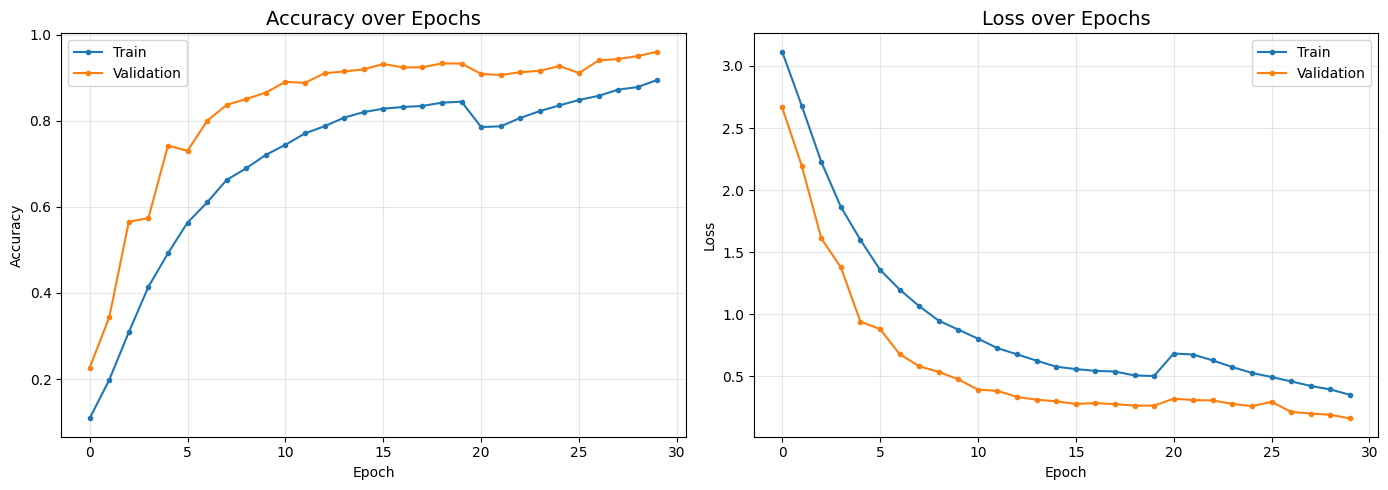

In [11]:
# ── Cell 9: Accuracy & Loss Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs, label='Train', marker='o', markersize=3)
axes[0].plot(val_accs,   label='Validation', marker='o', markersize=3)
axes[0].set_title("Accuracy over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train', marker='o', markersize=3)
axes[1].plot(val_losses,   label='Validation', marker='o', markersize=3)
axes[1].set_title("Loss over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Cell 10: Evaluation on Test Set ──────────────────────────────────────────
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        preds  = torch.max(model(images), 1)[1]
        y_true.extend(lbls.numpy())
        y_pred.extend(preds.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=classes))

Test Accuracy: 0.9613

              precision    recall  f1-score   support

     yaleB11       0.98      1.00      0.99        87
     yaleB12       0.99      0.98      0.98        88
     yaleB13       0.95      1.00      0.97        88
     yaleB15       0.92      0.95      0.94        88
     yaleB16       0.92      0.97      0.94        87
     yaleB17       0.91      0.92      0.92        88
     yaleB18       1.00      1.00      1.00        88
     yaleB19       0.98      0.97      0.97        88
     yaleB20       0.91      0.97      0.94        88
     yaleB21       0.97      0.97      0.97        87
     yaleB22       0.94      0.97      0.96        88
     yaleB23       1.00      0.97      0.98        88
     yaleB24       0.97      0.94      0.95        88
     yaleB25       0.96      0.91      0.93        87
     yaleB26       0.97      0.97      0.97        88
     yaleB27       1.00      1.00      1.00        87
     yaleB28       0.93      1.00      0.96        88
    

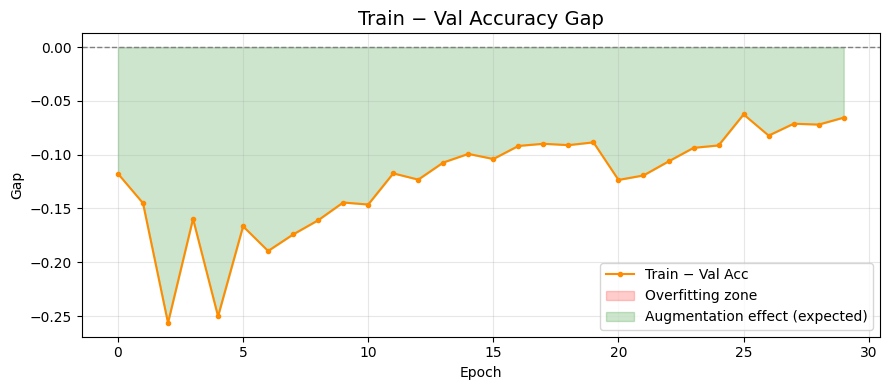

In [13]:
# ── Cell 11: Overfitting Gap ──────────────────────────────────────────────────
# NOTE: A negative gap (val > train) is NORMAL here because:
#   - Train images are augmented (harder task → lower apparent accuracy)
#   - Val/Test images are clean
# What you actually want to see: gap converging toward 0 over epochs.
gap = np.array(train_accs) - np.array(val_accs)

plt.figure(figsize=(9, 4))
plt.plot(gap, color='darkorange', marker='o', markersize=3, label='Train − Val Acc')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.fill_between(range(len(gap)), gap, 0, where=(gap > 0), alpha=0.2, color='red',   label='Overfitting zone')
plt.fill_between(range(len(gap)), gap, 0, where=(gap < 0), alpha=0.2, color='green', label='Augmentation effect (expected)')
plt.title("Train − Val Accuracy Gap", fontsize=14)
plt.xlabel("Epoch"); plt.ylabel("Gap")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()

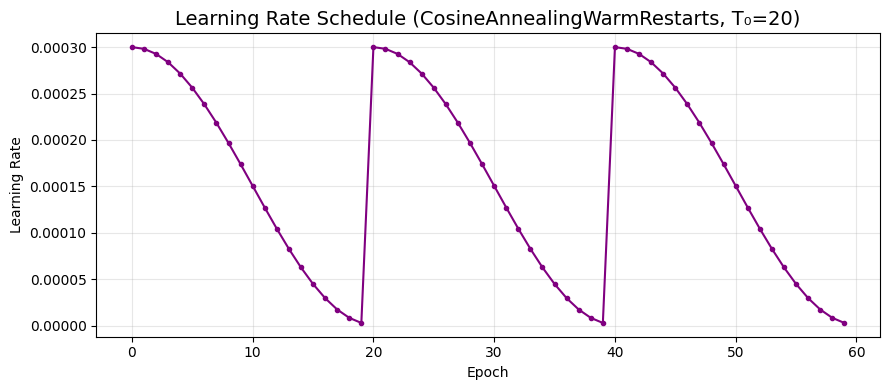

In [14]:
# ── Cell 12: Learning Rate Schedule Visualization ────────────────────────────
# Simulate CosineAnnealingWarmRestarts for T_0=20 over 60 epochs
# FIX: Step optimizer before scheduler to avoid PyTorch warning
_tmp_opt = optim.AdamW([torch.tensor(1.0, requires_grad=True)], lr=3e-4)
_tmp_sch = optim.lr_scheduler.CosineAnnealingWarmRestarts(_tmp_opt, T_0=20, T_mult=1, eta_min=1e-6)
lrs = []
for ep in range(60):
    lrs.append(_tmp_sch.get_last_lr()[0])
    _tmp_opt.step()          # optimizer step FIRST
    _tmp_sch.step(ep + 1)    # then scheduler

plt.figure(figsize=(9, 4))
plt.plot(lrs, color='purple', marker='o', markersize=3)
plt.title("Learning Rate Schedule (CosineAnnealingWarmRestarts, T₀=20)", fontsize=14)
plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lr_schedule.png", dpi=150, bbox_inches='tight')
plt.show()

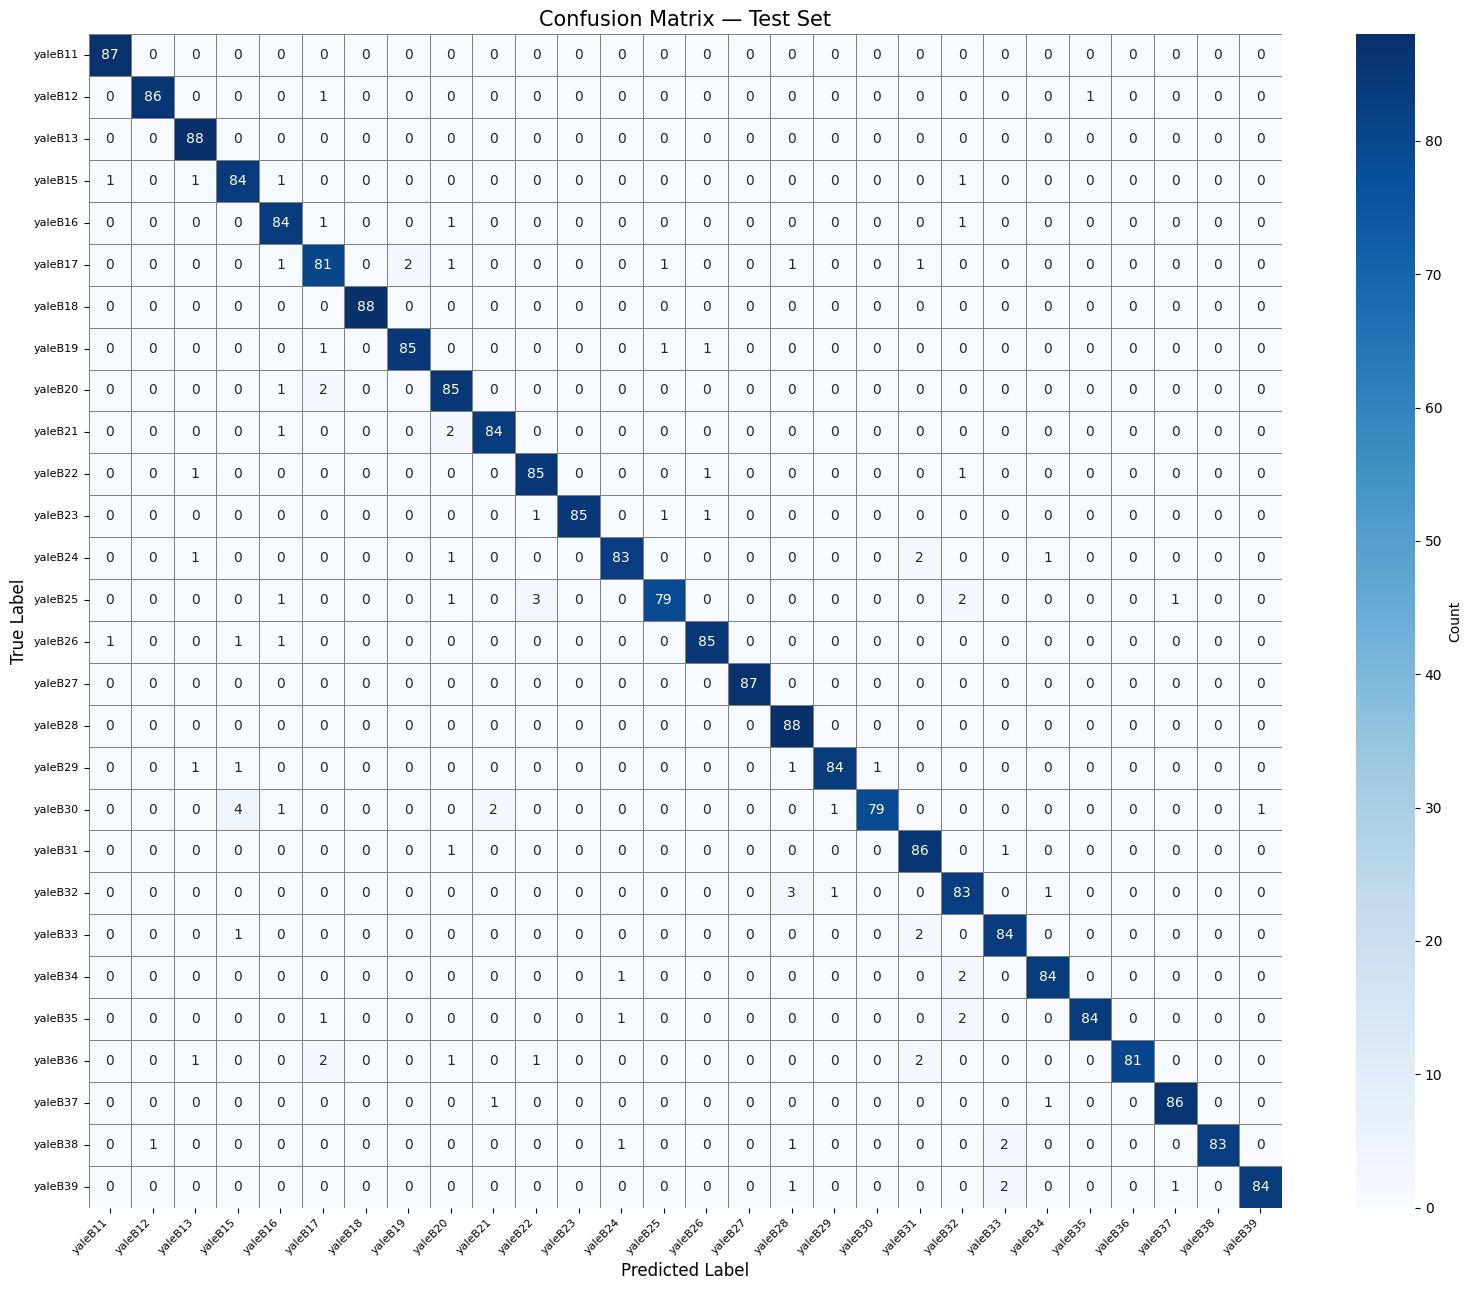

In [15]:
# ── Cell 13: Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

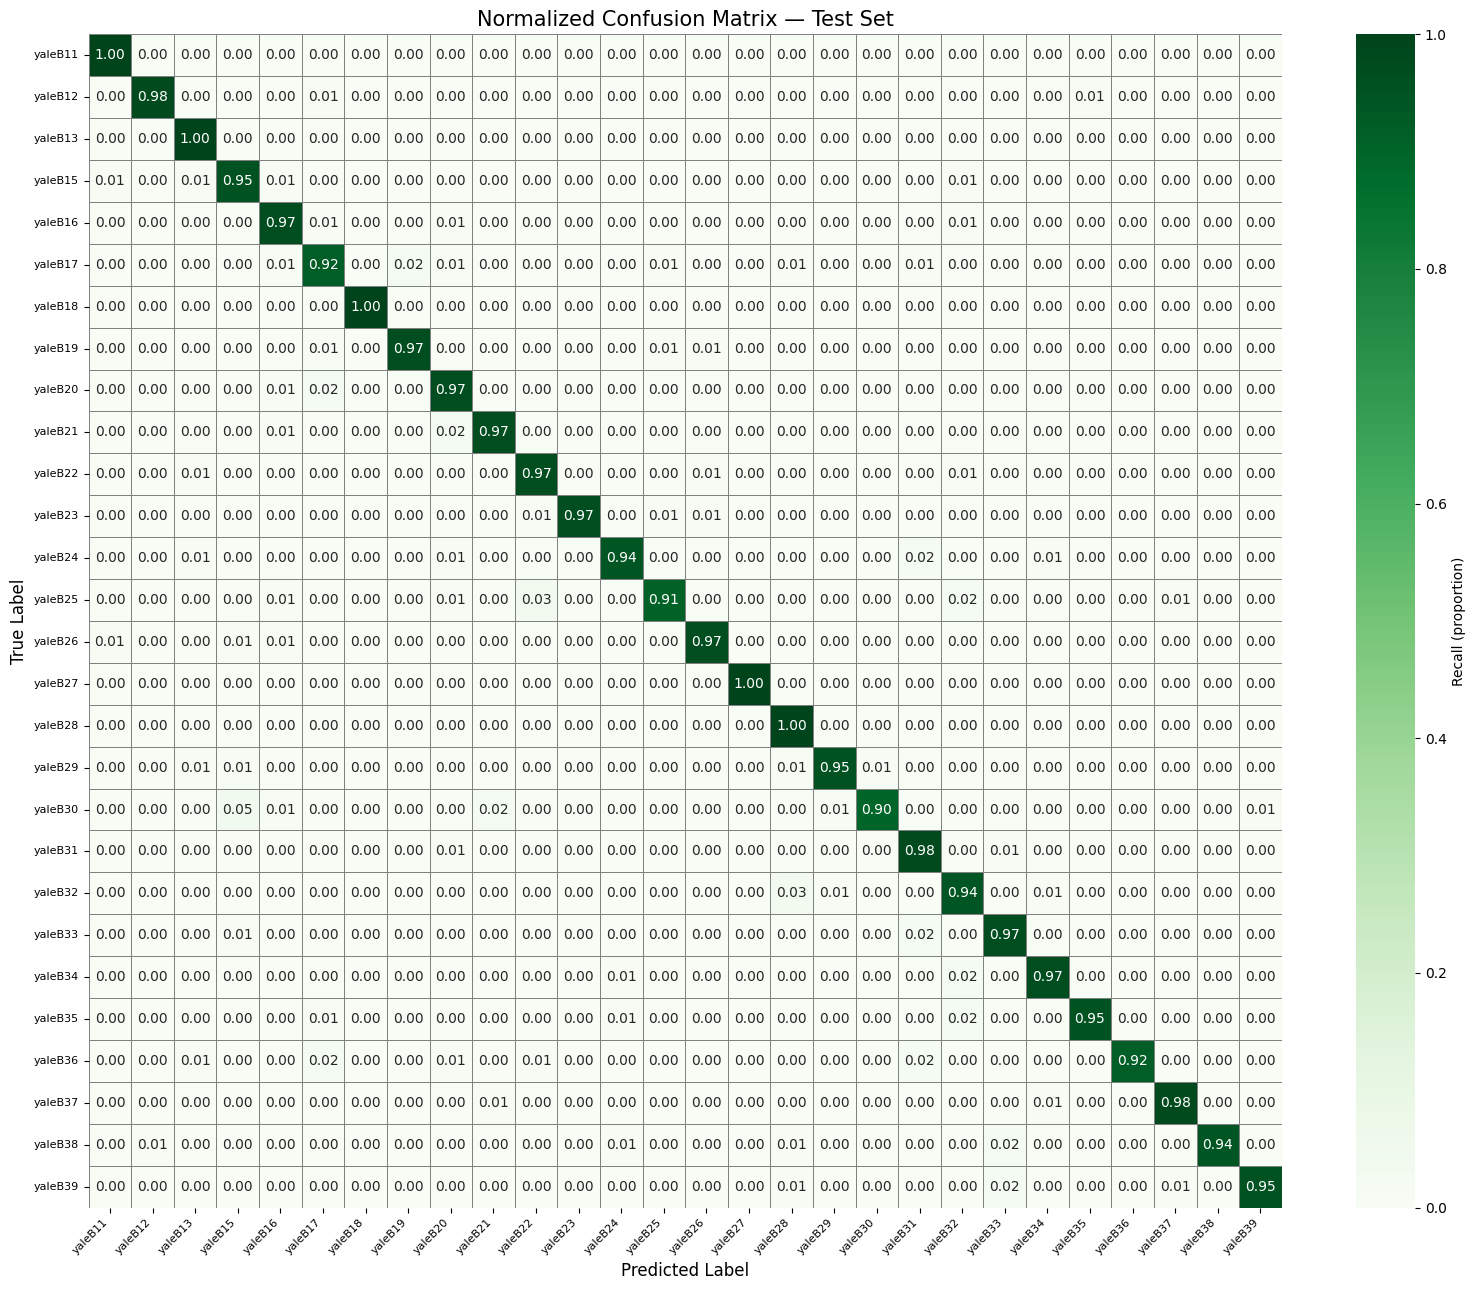

In [16]:
# ── Cell 14: Normalized Confusion Matrix ─────────────────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 13))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1,
            cbar_kws={'label': 'Recall (proportion)'})
plt.title("Normalized Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=150, bbox_inches='tight')
plt.show()

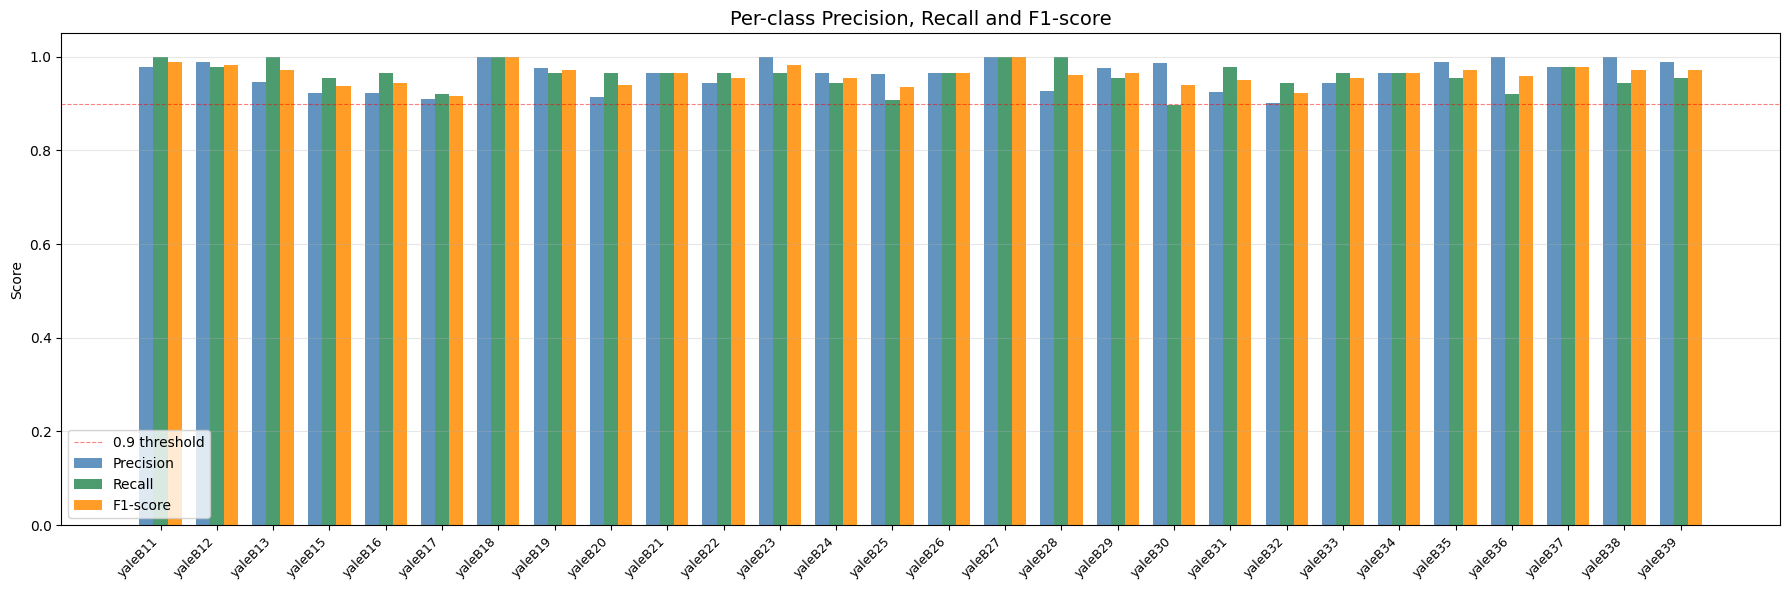

In [17]:
# ── Cell 15: Per-class Precision / Recall / F1 ───────────────────────────────
report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

prec = [report[c]['precision'] for c in classes]
rec  = [report[c]['recall']    for c in classes]
f1   = [report[c]['f1-score']  for c in classes]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width, prec, width, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x,         rec,  width, label='Recall',    color='seagreen',   alpha=0.85)
ax.bar(x + width, f1,   width, label='F1-score',  color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Per-class Precision, Recall and F1-score", fontsize=14)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='0.9 threshold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

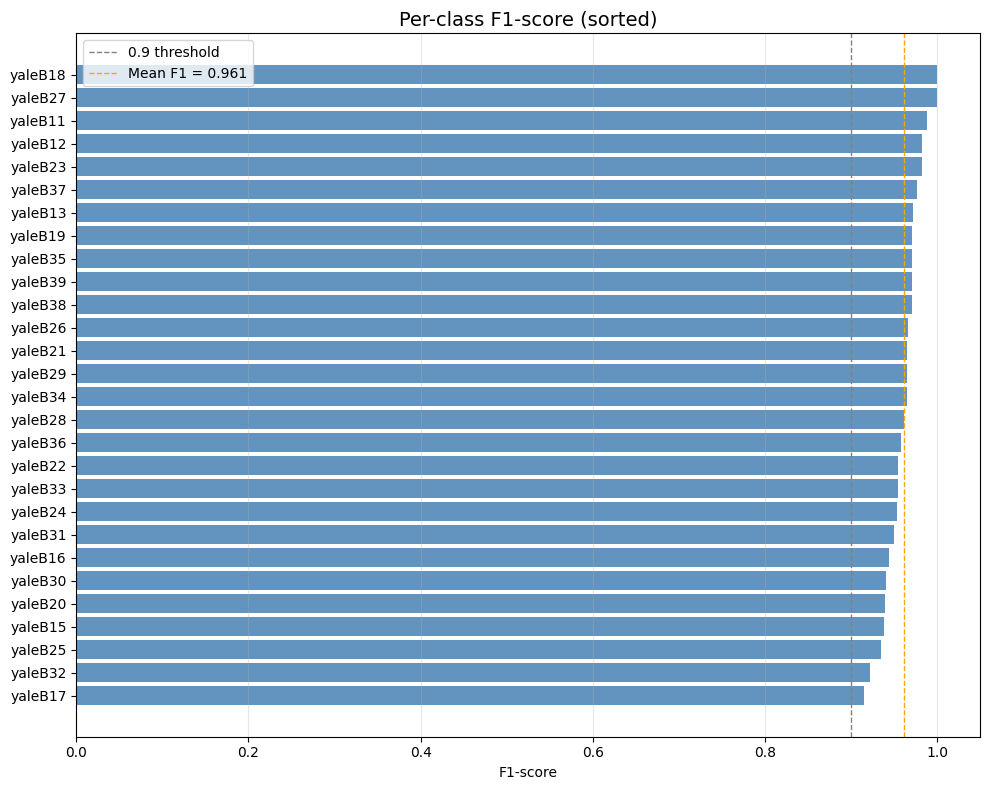

In [18]:
# ── Cell 16: Per-class F1 Sorted Bar ─────────────────────────────────────────
sorted_idx     = np.argsort(f1)
sorted_classes = [classes[i] for i in sorted_idx]
sorted_f1      = [f1[i]      for i in sorted_idx]
colors         = ['red' if v < 0.85 else 'steelblue' for v in sorted_f1]

plt.figure(figsize=(10, 8))
bars = plt.barh(sorted_classes, sorted_f1, color=colors, alpha=0.85)
plt.axvline(0.9, color='gray', linestyle='--', linewidth=1, label='0.9 threshold')
plt.axvline(np.mean(sorted_f1), color='orange', linestyle='--', linewidth=1,
            label=f'Mean F1 = {np.mean(sorted_f1):.3f}')
plt.xlabel("F1-score"); plt.title("Per-class F1-score (sorted)", fontsize=14)
plt.xlim(0, 1.05); plt.legend(); plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("f1_sorted.png", dpi=150, bbox_inches='tight')
plt.show()

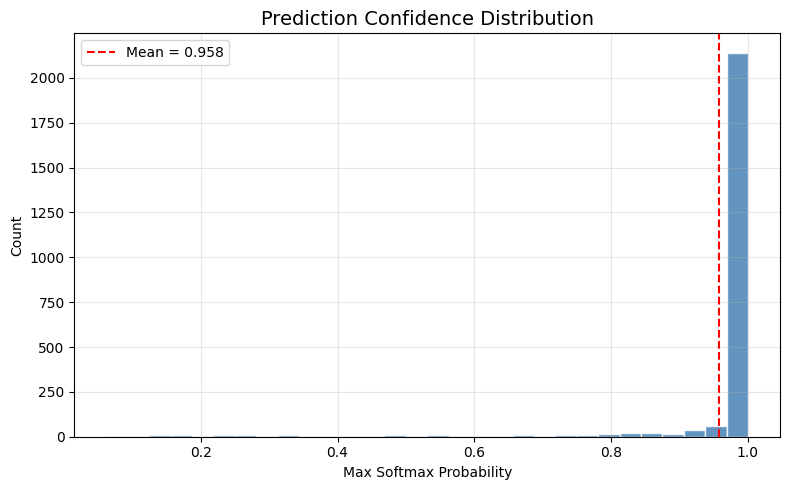

In [19]:
# ── Cell 17: Confidence Histogram ────────────────────────────────────────────
confidences = []
model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images    = images.to(device)
        probs     = torch.softmax(model(images), dim=1)
        max_probs, _ = torch.max(probs, 1)
        confidences.extend(max_probs.cpu().numpy())

mean_conf = np.mean(confidences)
plt.figure(figsize=(8, 5))
plt.hist(confidences, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(mean_conf, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {mean_conf:.3f}')
plt.title("Prediction Confidence Distribution", fontsize=14)
plt.xlabel("Max Softmax Probability"); plt.ylabel("Count")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

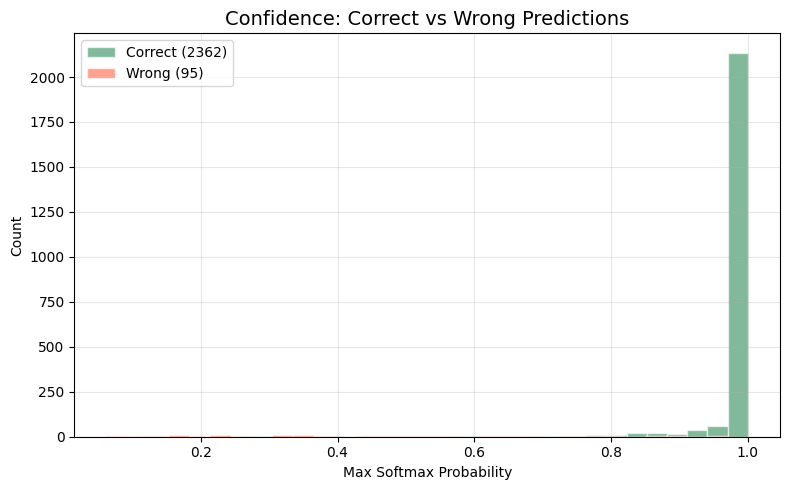

In [20]:
# ── Cell 18: Confidence — Correct vs Wrong ───────────────────────────────────
correct_conf, wrong_conf = [], []
model.eval()
with torch.no_grad():
    for images, lbls in test_loader:
        images  = images.to(device)
        probs   = torch.softmax(model(images), dim=1)
        max_probs, preds = torch.max(probs, 1)
        for conf, pred, true in zip(max_probs.cpu().numpy(),
                                     preds.cpu().numpy(),
                                     lbls.numpy()):
            (correct_conf if pred == true else wrong_conf).append(conf)

plt.figure(figsize=(8, 5))
plt.hist(correct_conf, bins=30, alpha=0.6, color='seagreen',
         label=f'Correct ({len(correct_conf)})', edgecolor='white')
plt.hist(wrong_conf,   bins=30, alpha=0.6, color='tomato',
         label=f'Wrong ({len(wrong_conf)})',   edgecolor='white')
plt.title("Confidence: Correct vs Wrong Predictions", fontsize=14)
plt.xlabel("Max Softmax Probability"); plt.ylabel("Count")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_correct_vs_wrong.png", dpi=150, bbox_inches='tight')
plt.show()

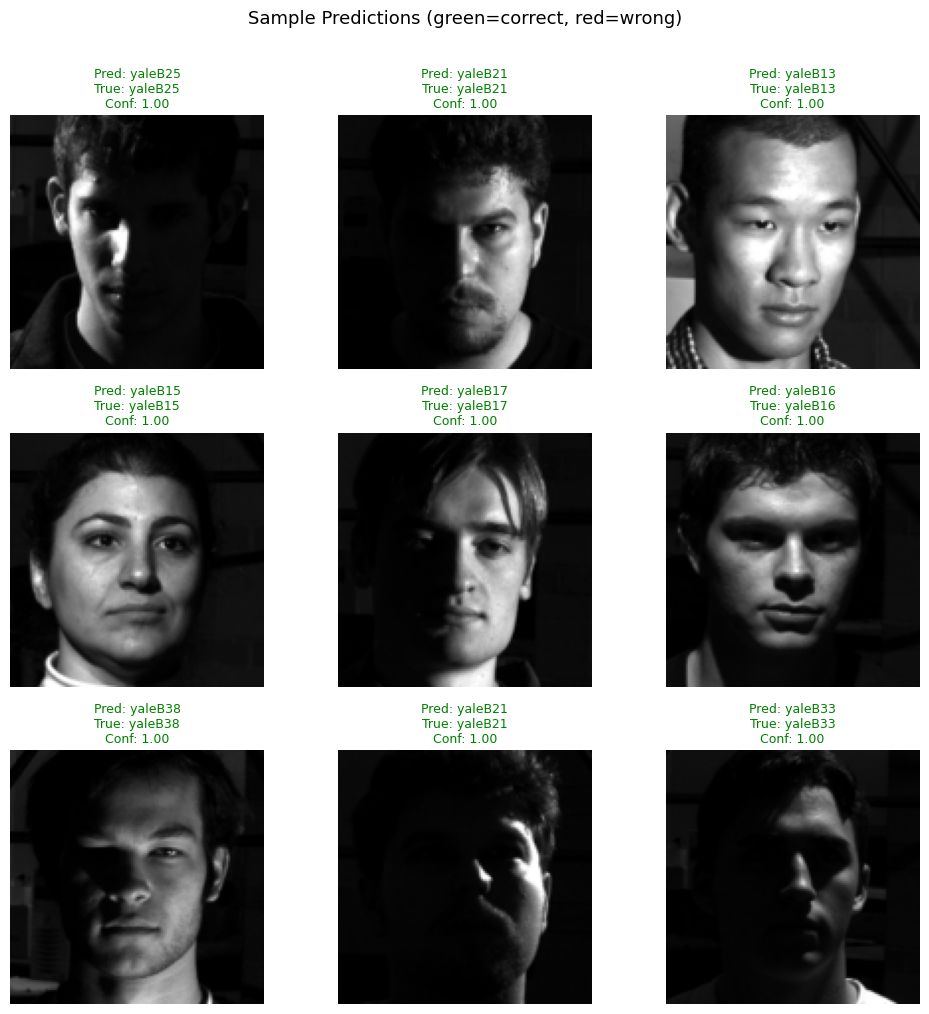

In [21]:
# ── Cell 19: Sample Predictions Grid (3×3) ───────────────────────────────────
images_batch, lbls_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

model.eval()
with torch.no_grad():
    probs_batch = torch.softmax(model(images_batch), dim=1)
    confs_batch, preds_batch = torch.max(probs_batch, 1)

images_batch = images_batch.cpu()

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_batch[i].squeeze(), cmap='gray')
    pred_name = classes[preds_batch[i]]
    true_name = classes[lbls_batch[i]]
    conf_val  = confs_batch[i].item()
    color     = 'green' if preds_batch[i] == lbls_batch[i] else 'red'
    ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}\nConf: {conf_val:.2f}",
                 fontsize=9, color=color)
    ax.axis('off')

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

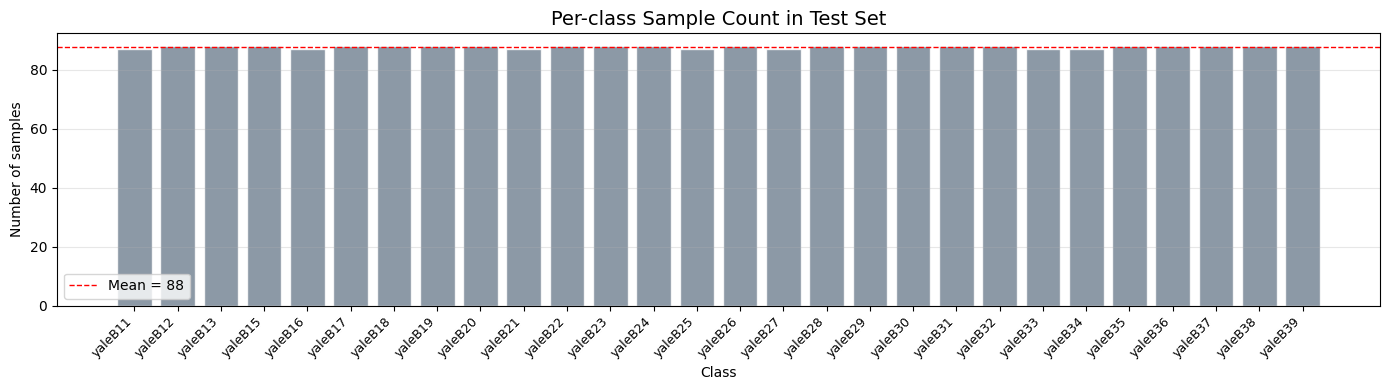

  Best Validation Accuracy : 0.9605 (96.05%)
  Test Accuracy            : 0.9613 (96.13%)
  Macro F1                 : 0.9614
  Epochs trained           : 30
  Weakest class (F1)       : yaleB17 → 0.915
  Strongest class (F1)     : yaleB18 → 1.000


In [22]:
# ── Cell 20: Per-class Support & Summary ─────────────────────────────────────
support = [report[c]['support'] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, support, color='slategray', alpha=0.8, edgecolor='white')
plt.title("Per-class Sample Count in Test Set", fontsize=14)
plt.xlabel("Class"); plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(np.mean(support), color='red', linestyle='--', linewidth=1,
            label=f'Mean = {np.mean(support):.0f}')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_support.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Best Validation Accuracy : {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
print(f"  Test Accuracy            : {accuracy_score(y_true, y_pred):.4f} ({accuracy_score(y_true, y_pred)*100:.2f}%)")
print(f"  Macro F1                 : {report['macro avg']['f1-score']:.4f}")
print(f"  Epochs trained           : {len(train_accs)}")
print(f"  Weakest class (F1)       : {classes[np.argmin(f1)]} → {min(f1):.3f}")
print(f"  Strongest class (F1)     : {classes[np.argmax(f1)]} → {max(f1):.3f}")
print("=" * 55)